# 1.2 Kernel rank

1.2 Kernel rank: numeric rank + normalised singular-value spectrum for
every kernel in the supplied bank at k=15.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import kernel_bank, numeric_rank

ROOT = Path.cwd().parents[1]

In [4]:
K = 15
bank = kernel_bank(K)

rows = []
spectra = {}
for name, kernel in bank.items():
    rank, s, tol = numeric_rank(kernel)
    s_norm = s / s.max()  # normalised singular value spectrum
    spectra[name] = s_norm
    rows.append((name, rank, s.max(), tol, s_norm[rank] if rank < len(s_norm) else 0.0))

In [5]:
# --- text table -----------------------------------------------------------
print(f"{'kernel':16s} {'rank':>5s} {'sigma_max':>12s} {'tol':>12s} {'sigma[rank]/max':>16s}")
for name, rank, smax, tol, s_next in rows:
    print(f"{name:16s} {rank:5d} {smax:12.4e} {tol:12.4e} {s_next:16.4e}")

kernel            rank    sigma_max          tol  sigma[rank]/max
box                  1   6.6667e-02   2.2204e-16       0.0000e+00
gaussian             1   1.1341e-01   3.7773e-16       5.7476e-17
sobel3               1   3.4641e+00   2.3076e-15       1.0135e-16
log                  2   9.6797e-01   3.2240e-15       8.8253e-17
log_dc_removed       3   9.6381e-01   3.2101e-15       8.4096e-17
motion_0deg          1   2.5820e-01   8.5998e-16       0.0000e+00
motion_45deg        15   6.6667e-02   2.2204e-16       0.0000e+00
disk                 5   7.1102e-02   2.3682e-16       1.7161e-17
random              15   4.1244e-02   1.3737e-16       0.0000e+00


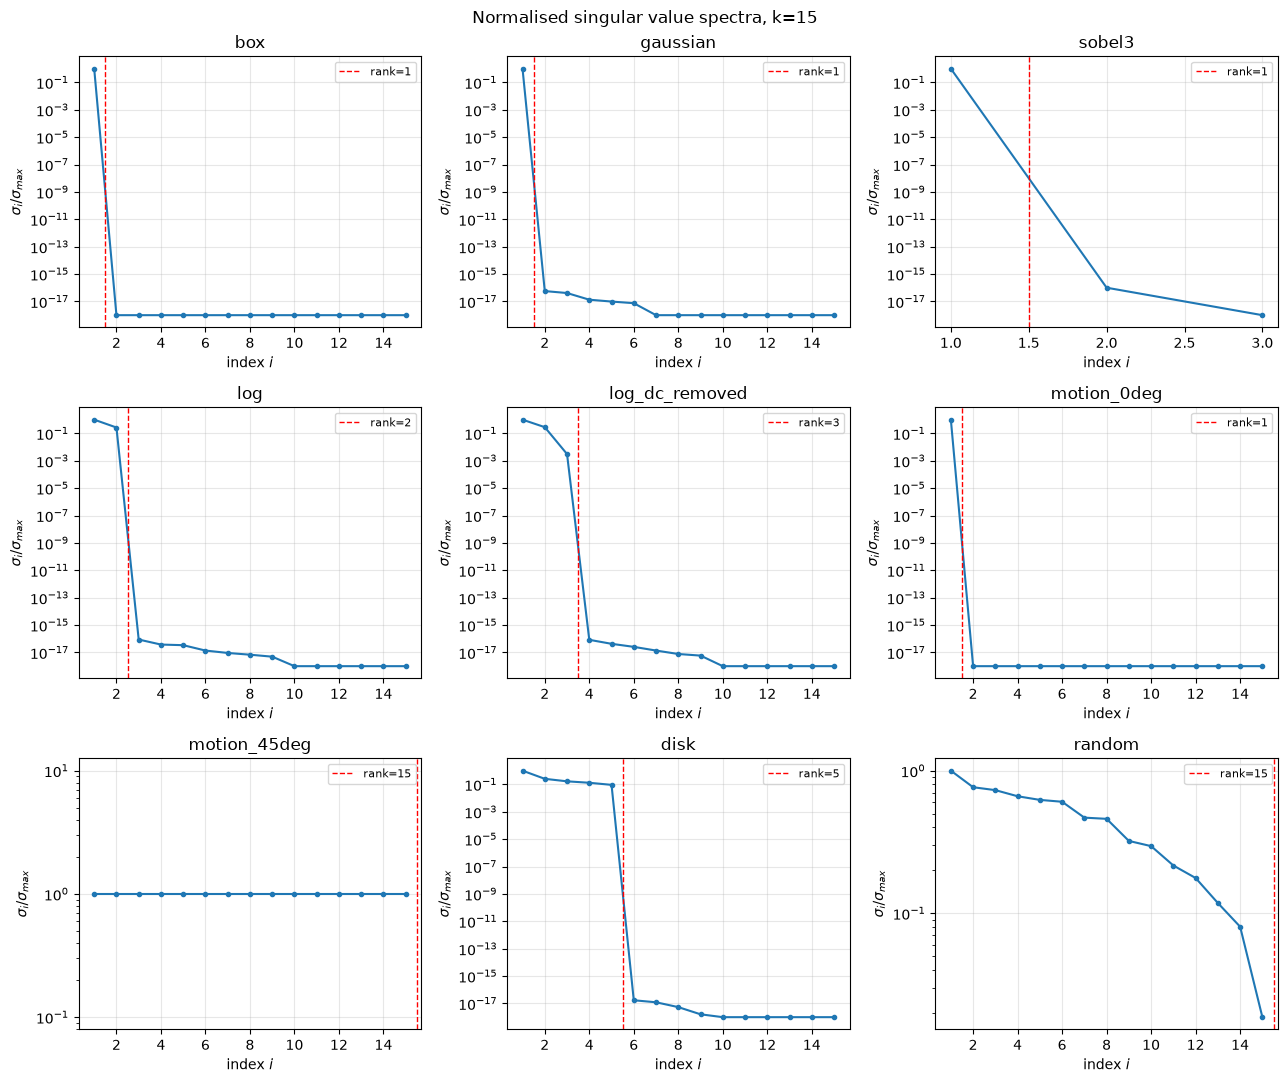

In [6]:
# --- spectrum plot (log scale, one panel per kernel) -----------------------
names = list(bank.keys())
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for ax, name in zip(axes.ravel(), names):
    s_norm = spectra[name]
    rank = [r for n, r, *_ in rows if n == name][0]
    ax.semilogy(np.arange(1, len(s_norm) + 1), np.clip(s_norm, 1e-18, None), "o-", markersize=3)
    ax.axvline(rank + 0.5, color="red", linestyle="--", linewidth=1,
               label=f"rank={rank}")
    ax.set_title(name)
    ax.set_xlabel("index $i$")
    ax.set_ylabel("$\\sigma_i / \\sigma_{max}$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle(f"Normalised singular value spectra, k={K}")
fig.tight_layout()
plt.show()